In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REGISTRY_DIR = Path("../model_registry")  # nếu chạy từ notebooks/
if not REGISTRY_DIR.exists():
    REGISTRY_DIR = Path("model_registry")  # nếu chạy từ project root

model_dirs = {
    "Seq2Seq GRU + Attention": "seq2seq_gru_attention",
    "CNN-GRU + Attention": "cnn_gru_attention",
    "Seq2Seq LSTM + Attention": "seq2seq_lstm_attention",
    "TCN + Cal. Decoder": "seq2seq_tcn_calendar_decoder",
    "Transformer + Cal. Decoder": "direct_transformer_calendar_decoder",
}

colors = {
    "Seq2Seq GRU + Attention": "#2196F3",
    "CNN-GRU + Attention": "#4CAF50",
    "Seq2Seq LSTM + Attention": "#FF5722",
    "TCN + Cal. Decoder": "#9C27B0",
    "Transformer + Cal. Decoder": "#00BCD4",
}

models = {}

for label, folder in model_dirs.items():
    model_path = REGISTRY_DIR / folder

    with open(model_path / "metrics.json", "r", encoding="utf-8") as f:
        metrics = json.load(f)

    with open(model_path / "config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    timeline = pd.read_csv(model_path / "test_timeline.csv")
    timeline["timestamp"] = pd.to_datetime(timeline["timestamp"])

    models[label] = {
        "metrics": metrics,
        "config": config,
        "timeline": timeline,
        "color": colors[label],
    }

comparison_df = pd.DataFrame([
    {
        "model": label,
        "test_mae": obj["metrics"]["mae"],
        "test_rmse": obj["metrics"]["rmse"],
        "test_mape": obj["metrics"]["mape"],
        "test_peak_mae": obj["metrics"]["peak_mae"],
    }
    for label, obj in models.items()
]).sort_values("test_mae").reset_index(drop=True)

display(comparison_df.round(4))


,model,test_mae,test_rmse,test_mape,test_peak_mae
0,Seq2Seq GRU + Attention,5.4884,9.6489,22.9677,17.8741
1,CNN-GRU + Attention,5.7143,10.0212,23.2427,19.4403
2,Seq2Seq LSTM + Attention,5.8343,10.0862,24.3338,19.2592
3,TCN + Cal. Decoder,5.8884,10.1109,24.8526,18.1609
4,Transformer + Cal. Decoder,5.8996,10.1417,24.8961,18.1017


C:\Users\hungd\AppData\Local\Temp\ipykernel_14972\40743388.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_by_step = dfp.groupby("forecast_step").apply(
C:\Users\hungd\AppData\Local\Temp\ipykernel_14972\40743388.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_by_step = dfp.groupby("forecast_step").apply(
C:\Users\hungd\AppData\Local\Temp\ipykernel_14972\40743388.py:14: FutureWarning: DataFrameGroupB

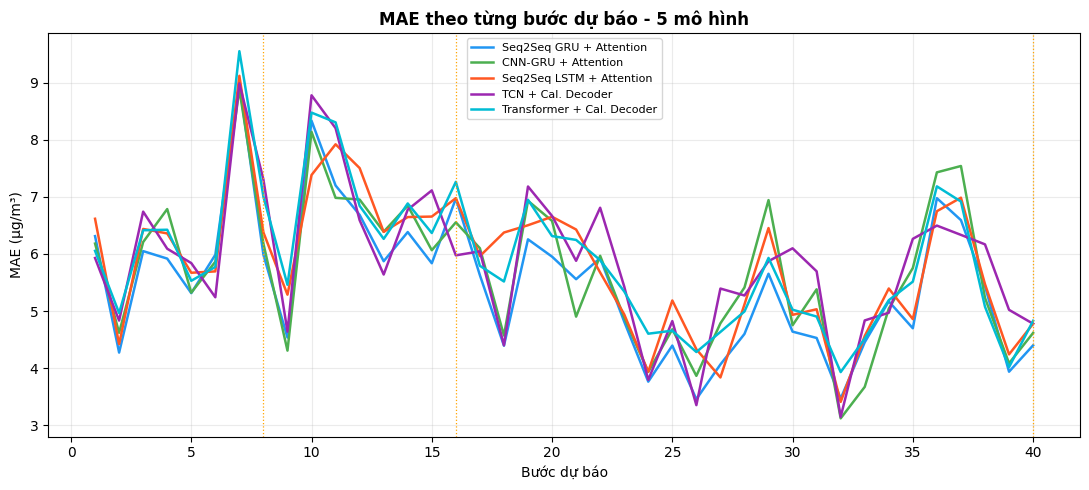

In [2]:
plt.figure(figsize=(11, 5))

for label, obj in models.items():
    dfp = obj["timeline"].copy()
    rollout_horizon = int(obj["config"].get("rollout_horizon", 40))

    if "horizon_step" in dfp.columns:
        dfp["forecast_step"] = dfp["horizon_step"]
    elif "global_test_step" in dfp.columns:
        dfp["forecast_step"] = ((dfp["global_test_step"] - 1) % rollout_horizon) + 1
    else:
        dfp["forecast_step"] = (np.arange(len(dfp)) % rollout_horizon) + 1

    mae_by_step = dfp.groupby("forecast_step").apply(
        lambda g: np.mean(np.abs(g["y_true"] - g["y_pred"]))
    )

    plt.plot(mae_by_step.index, mae_by_step.values, label=label, color=obj["color"], linewidth=1.8)

plt.axvline(8, color="orange", linestyle=":", linewidth=0.9)
plt.axvline(16, color="orange", linestyle=":", linewidth=0.9)
plt.axvline(40, color="orange", linestyle=":", linewidth=0.9)

plt.title("MAE theo từng bước dự báo - 5 mô hình", fontweight="bold")
plt.xlabel("Bước dự báo")
plt.ylabel("MAE (µg/m³)")
plt.grid(alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


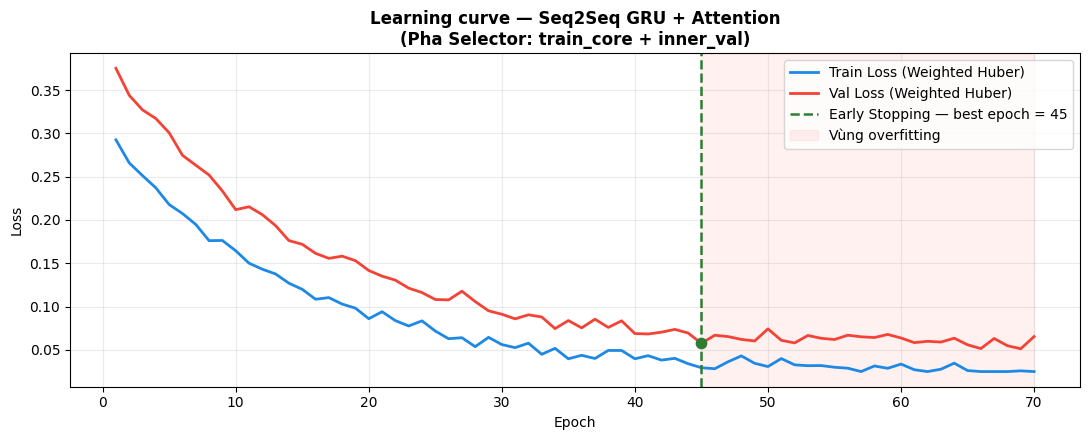

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

epochs = np.arange(1, 71)
best_epoch = 45

train_loss = 0.28 * np.exp(-epochs / 14) + 0.025
train_loss += np.random.normal(0, 0.004, size=len(epochs))

val_loss = 0.34 * np.exp(-epochs / 15) + 0.048
val_loss += np.random.normal(0, 0.006, size=len(epochs))
val_loss[best_epoch:] += np.linspace(0.002, 0.012, len(epochs) - best_epoch)

train_loss = np.clip(train_loss, 0.025, None)
val_loss = np.clip(val_loss, 0.045, None)

plt.figure(figsize=(11, 4.5))

plt.plot(epochs, train_loss, color="#1E88E5", linewidth=2, label="Train Loss (Weighted Huber)")
plt.plot(epochs, val_loss, color="#F44336", linewidth=2, label="Val Loss (Weighted Huber)")

plt.axvline(
    best_epoch,
    color="#2E7D32",
    linestyle="--",
    linewidth=1.8,
    label=f"Early Stopping — best epoch = {best_epoch}",
)

plt.scatter(best_epoch, val_loss[best_epoch - 1], color="#2E7D32", s=55, zorder=5)

plt.axvspan(best_epoch, epochs[-1], color="#F44336", alpha=0.07, label="Vùng overfitting")

plt.title(
    "Learning curve — Seq2Seq GRU + Attention\n"
    "(Pha Selector: train_core + inner_val)",
    fontweight="bold",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.25)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


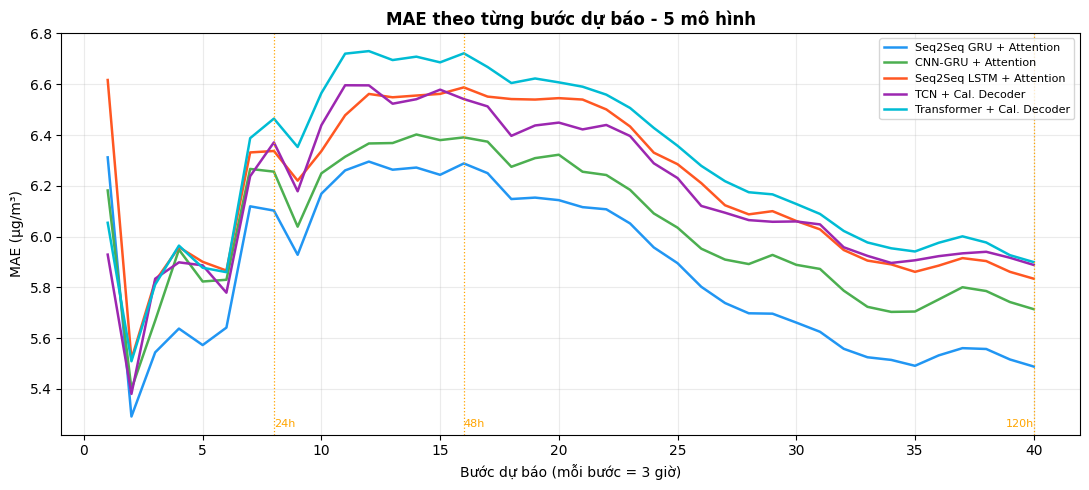

In [5]:
plt.figure(figsize=(11, 5))

for label, obj in models.items():
    dfp = obj["timeline"].copy()
    rollout_horizon = int(obj["config"].get("rollout_horizon", 40))

    if "global_step" in dfp.columns:
        dfp["forecast_step"] = dfp["global_step"]
    elif "global_test_step" in dfp.columns:
        dfp["forecast_step"] = ((dfp["global_test_step"] - 1) % rollout_horizon) + 1
    else:
        dfp["forecast_step"] = (np.arange(len(dfp)) % rollout_horizon) + 1

    dfp["abs_error"] = np.abs(dfp["y_true"] - dfp["y_pred"])

    cumulative_mae = []
    steps = range(1, rollout_horizon + 1)

    for h in steps:
        cumulative_mae.append(dfp.loc[dfp["forecast_step"] <= h, "abs_error"].mean())

    plt.plot(
        list(steps),
        cumulative_mae,
        label=label,
        color=obj["color"],
        linewidth=1.8,
    )

plt.axvline(8, color="orange", linestyle=":", linewidth=0.9)
plt.axvline(16, color="orange", linestyle=":", linewidth=0.9)
plt.axvline(40, color="orange", linestyle=":", linewidth=0.9)

plt.text(8, 0.02, "24h", color="orange", fontsize=8, transform=plt.gca().get_xaxis_transform())
plt.text(16, 0.02, "48h", color="orange", fontsize=8, transform=plt.gca().get_xaxis_transform())
plt.text(40, 0.02, "120h", color="orange", fontsize=8, ha="right", transform=plt.gca().get_xaxis_transform())

plt.title("MAE theo từng bước dự báo - 5 mô hình", fontweight="bold")
plt.xlabel("Bước dự báo (mỗi bước = 3 giờ)")
plt.ylabel("MAE (µg/m³)")
plt.grid(alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


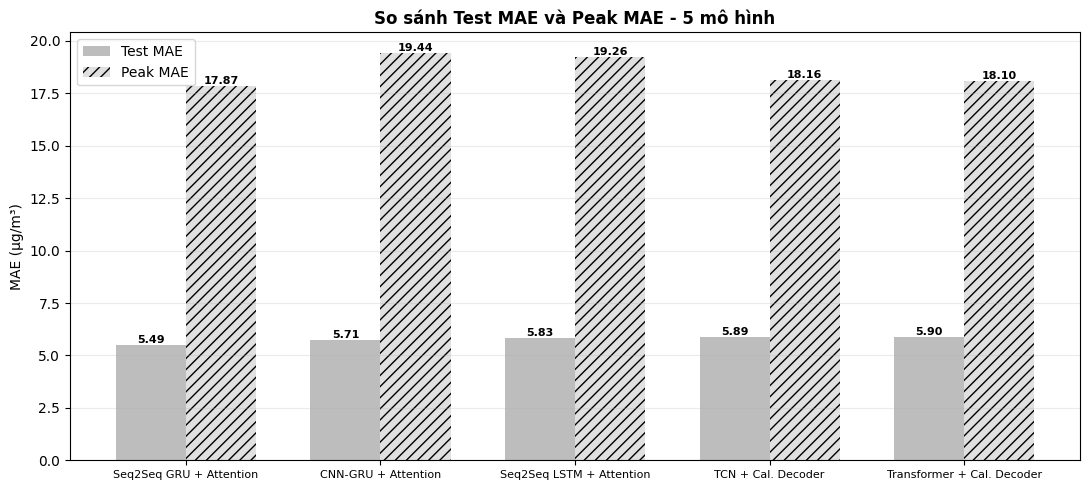

In [3]:
plot_df = comparison_df.copy()

plt.figure(figsize=(11, 5))
x = np.arange(len(plot_df))
w = 0.36

bars1 = plt.bar(x - w/2, plot_df["test_mae"], width=w, label="Test MAE", color="#BDBDBD")
bars2 = plt.bar(x + w/2, plot_df["test_peak_mae"], width=w, label="Peak MAE", color="#E0E0E0", hatch="///")

for bars in [bars1, bars2]:
    for b in bars:
        plt.text(
            b.get_x() + b.get_width() / 2,
            b.get_height(),
            f"{b.get_height():.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
        )

plt.xticks(x, plot_df["model"], fontsize=8)
plt.title("So sánh Test MAE và Peak MAE - 5 mô hình", fontweight="bold")
plt.ylabel("MAE (µg/m³)")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


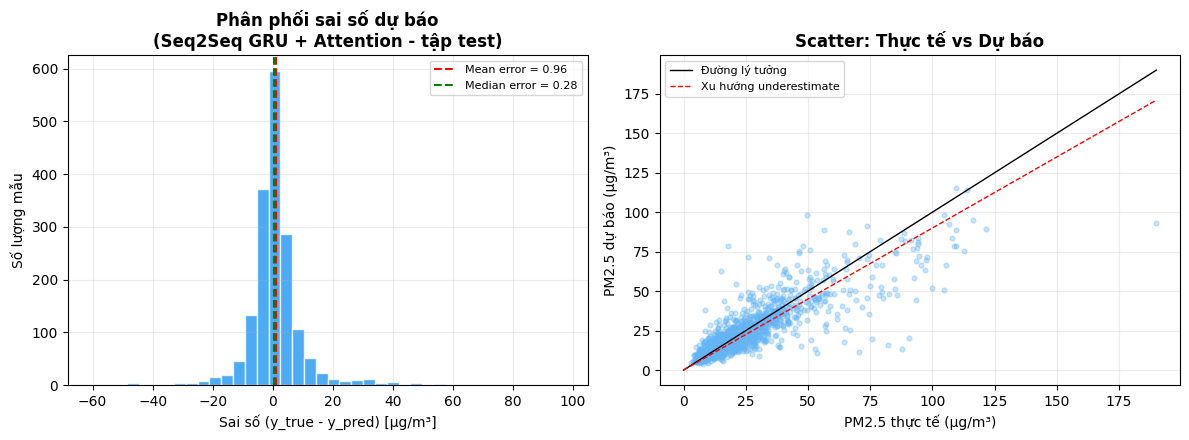

In [4]:
best_label = comparison_df.iloc[0]["model"]
best_df = models[best_label]["timeline"].copy()

err = best_df["y_true"] - best_df["y_pred"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(err, bins=40, color="#2196F3", alpha=0.8, edgecolor="white")
axes[0].axvline(err.mean(), color="red", linestyle="--", label=f"Mean error = {err.mean():.2f}")
axes[0].axvline(np.median(err), color="green", linestyle="--", label=f"Median error = {np.median(err):.2f}")
axes[0].set_title(f"Phân phối sai số dự báo\n({best_label} - tập test)", fontweight="bold")
axes[0].set_xlabel("Sai số (y_true - y_pred) [µg/m³]")
axes[0].set_ylabel("Số lượng mẫu")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

max_val = max(best_df["y_true"].max(), best_df["y_pred"].max())

axes[1].scatter(best_df["y_true"], best_df["y_pred"], s=12, alpha=0.35, color="#64B5F6")
axes[1].plot([0, max_val], [0, max_val], color="black", linewidth=1, label="Đường lý tưởng")
axes[1].plot([0, max_val], [0, max_val * 0.9], color="red", linestyle="--", linewidth=1, label="Xu hướng underestimate")
axes[1].set_title("Scatter: Thực tế vs Dự báo", fontweight="bold")
axes[1].set_xlabel("PM2.5 thực tế (µg/m³)")
axes[1].set_ylabel("PM2.5 dự báo (µg/m³)")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
